The general problem is to take a matrix that represents a single homing of shape (frames, neurons) and assign it a class. I.e did the homing target the left edge, the right edge, or neither. The data preperation will be key here.

Data prep thoughts:
- Are the classes balanced, i.e there are equal number of homings to the left and right
- Have we looked at the right time window, i.e the planning to go left or right could be 0.1 s before or 0.2 second before, or a time window
  - so we need some sweep for this feature
- We need a homing ID assigned to each matrix so that we can identify the homings when we concate it into a big matrix for input to the model
- We need held out homings where the mouse is basically straight

Dimentionality reduction:
- We could perform PCA although it's not clear whether this will help the classification given the linear assumptions and also the order basis in terms of variation
- We could try a non-linear classifer as well. Maybe T-SNE or UMAP

Classifications:
- We could start with a multi-nomial classifier e.g left, right or not
  - Esentially what we are doing here is classifying the neural data at each frame, there is no time component to this model
- Then if that performs above chance we could move to a shallow LSTM to also capture time

Thoughts on many sessions:
- We will have to limit to sessions with enough data, somehow automatically quality check each session?

Random thoughts:
- can I decode spatial efficiecny as a proxy of choice?

Imports


In [1]:
#%matplotlib inline

In [2]:
import pickle
import os
from pathlib import Path

from sklearn.linear_model import LogisticRegression
import sklearn as sk
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from behave_analysis.utils.creating_directories import make_directory
from behave_analysis.visualize.visualize_utils import open_tracking_data
from behave_analysis.process.session import get_experiment
from behave_analysis.utils.arena_plotting import Arena
from behave_analysis.analyze.single_trial.preprocess_regression import PreprocessSingleTrialRegression

Find a good session with many homings and a few in session that are straight at the top of the arena
- 7th of May JAL 8 has 136 homings so will look at that

In [3]:
from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may
c_type = "good"
dir = make_directory(r"Z:\Jasmine_Laurence\single_trial_overview")
dir = Path(dir)
conditions = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]

In [4]:
loaded_session = get_experiment(JAL8_flip3_7may)
video_and_spike_data_path = os.path.join(loaded_session.base_path, loaded_session.processed_path, "good_video_spike_count_df.parquet")
homing_path = os.path.join(loaded_session.base_path, loaded_session.processed_path, "homings", "homings_obj.pkl")

# Load data
try:
    video_df = pl.read_csv(os.path.join(loaded_session.base_path, loaded_session.processed_path) + "\\" "full_video_dataframe.csv")
    with open(homing_path, "rb") as hf:
            homings_object = pickle.load(hf) 
            
    video_and_spike_data = pl.read_parquet(video_and_spike_data_path)
    frame_by_cluster_matrix = np.load(os.path.join(loaded_session.base_path, loaded_session.processed_path) + "\\" + "frame_by_" + c_type + "_cluster_matrix.npy")
    tracking_data = open_tracking_data(loaded_session)
    cluster_Ids = np.load(str(os.path.join(loaded_session.base_path, loaded_session.processed_path) + "/" + c_type + "_cluster_Ids.npy"))

except FileNotFoundError:
    print("One of the files was not found")

# If there is no barrier in this session hard code it based on a prior session
if not "barrier_loc" in tracking_data.keys():
    tracking_data["barrier_loc"] = [[224, 515], [797, 512], [510, 513]]

In [5]:
homings_object.__dir__()

['onset_frames',
 'offset_frames',
 'stimulus_durations',
 'start_locs',
 'end_locs',
 'avg_speed',
 'homing_angles_dic',
 'hdir_at_start',
 'spatial_efficiency',
 'trajectory_length',
 'homing_condition',
 '__module__',
 '__annotations__',
 '__doc__',
 '__dict__',
 '__weakref__',
 '__dataclass_params__',
 '__dataclass_fields__',
 '__init__',
 '__repr__',
 '__eq__',
 '__hash__',
 '__match_args__',
 '__new__',
 '__str__',
 '__getattribute__',
 '__setattr__',
 '__delattr__',
 '__lt__',
 '__le__',
 '__ne__',
 '__gt__',
 '__ge__',
 '__reduce_ex__',
 '__reduce__',
 '__subclasshook__',
 '__init_subclass__',
 '__format__',
 '__sizeof__',
 '__dir__',
 '__class__']

Plot spatial effiency distribution

In [6]:
plt.hist(homings_object.spatial_efficiency)

(array([ 3.,  5.,  2.,  8.,  3.,  5.,  5.,  6.,  7., 93.]),
 array([0.51436834, 0.56288881, 0.61140928, 0.65992975, 0.70845022,
        0.75697069, 0.80549116, 0.85401163, 0.9025321 , 0.95105257,
        0.99957304]),
 <BarContainer object of 10 artists>)

In [7]:
shelter_location = tracking_data["shelter_loc"]
barrier_location = tracking_data["barrier_loc"]
print(barrier_location)

[[798, 513], [228, 513], [np.int64(513), np.int64(513)]]


 Get behavioural data for each homing

In [8]:
def extract_behavioural_data_betwee_homing_onset_offset(homing_object: dict, video_df: pl.DataFrame) -> list:
    """Returns a list of behavioural dataframes for each homing event in the homing object."""
    homing_info = []
    for onset, offset in zip(homing_object.onset_frames, homing_object.offset_frames):
        homing = video_df[int(onset) - 1 : int(offset) - 1]  # Substract 1 to prevent off by one error
        homing = homing.select(
            [
                "frames",
                "mouse_x_position",
                "mouse_y_position",
                "hdir",
                "hsa",
                "h_preflipbar_a",
                "h_postflipbar_a",
            ]
        )
        homing_info.append(homing)
    return homing_info
homing_info = extract_behavioural_data_betwee_homing_onset_offset(homings_object, video_df)
print(homing_info[0].head())

shape: (5, 7)
┌────────┬────────────────┬────────────────┬──────────┬───────────┬────────────────┬───────────────┐
│ frames ┆ mouse_x_positi ┆ mouse_y_positi ┆ hdir     ┆ hsa       ┆ h_preflipbar_a ┆ h_postflipbar │
│ ---    ┆ on             ┆ on             ┆ ---      ┆ ---       ┆ ---            ┆ _a            │
│ i64    ┆ ---            ┆ ---            ┆ f64      ┆ f64       ┆ f64            ┆ ---           │
│        ┆ f64            ┆ f64            ┆          ┆           ┆                ┆ f64           │
╞════════╪════════════════╪════════════════╪══════════╪═══════════╪════════════════╪═══════════════╡
│ 9080   ┆ 231.176088     ┆ 223.000663     ┆ 1.138296 ┆ -2.34324  ┆ -1.663191      ┆ -2.726367     │
│ 9081   ┆ 230.364696     ┆ 226.954922     ┆ 1.081296 ┆ -2.283702 ┆ -1.599572      ┆ -2.668771     │
│ 9082   ┆ 229.670482     ┆ 230.899867     ┆ 1.008045 ┆ -2.208128 ┆ -1.519535      ┆ -2.595884     │
│ 9083   ┆ 229.098198     ┆ 234.795987     ┆ 0.919336 ┆ -2.117306 ┆ -1.423861

add homing id

In [9]:
def add_homing_id_to_homing_data(extracted_homing_info: list) -> list:
    """Adding the homing id (abitrary ascending interger) to the homing data.
    This is needed for the group cross validation object

    Args:
        extracted_homing_info (list): A list of homing dataframes for each homing period

    Returns:
        (list) of homing dataframes with the homing id added as a column
    """
    for idx, homing in enumerate(extracted_homing_info):
        updated_homing = homing.with_columns(pl.lit(idx).alias("homing_id"))
        extracted_homing_info[idx] = updated_homing
    return extracted_homing_info
homing_info = add_homing_id_to_homing_data(homing_info)
print(homing_info[0].head())


shape: (5, 8)
┌────────┬─────────────┬─────────────┬──────────┬───────────┬─────────────┬────────────┬───────────┐
│ frames ┆ mouse_x_pos ┆ mouse_y_pos ┆ hdir     ┆ hsa       ┆ h_preflipba ┆ h_postflip ┆ homing_id │
│ ---    ┆ ition       ┆ ition       ┆ ---      ┆ ---       ┆ r_a         ┆ bar_a      ┆ ---       │
│ i64    ┆ ---         ┆ ---         ┆ f64      ┆ f64       ┆ ---         ┆ ---        ┆ i32       │
│        ┆ f64         ┆ f64         ┆          ┆           ┆ f64         ┆ f64        ┆           │
╞════════╪═════════════╪═════════════╪══════════╪═══════════╪═════════════╪════════════╪═══════════╡
│ 9080   ┆ 231.176088  ┆ 223.000663  ┆ 1.138296 ┆ -2.34324  ┆ -1.663191   ┆ -2.726367  ┆ 0         │
│ 9081   ┆ 230.364696  ┆ 226.954922  ┆ 1.081296 ┆ -2.283702 ┆ -1.599572   ┆ -2.668771  ┆ 0         │
│ 9082   ┆ 229.670482  ┆ 230.899867  ┆ 1.008045 ┆ -2.208128 ┆ -1.519535   ┆ -2.595884  ┆ 0         │
│ 9083   ┆ 229.098198  ┆ 234.795987  ┆ 0.919336 ┆ -2.117306 ┆ -1.423861   ┆ -

Get the conditions assigned to each homing

In [10]:
homing_conditions = homings_object.homing_condition

Define some classes

Now how is best to assign classes to each homing:
- if I train on all of them and only test on those that are straight at homing onset, this means there will be arrows on all sorts of directions which might make classification hard
- actually going to try something fun and do it on spatial effiency

In [11]:
# If spatial effiency for a homing is above 0.9 then it is a good homing and give it a class of 1
# If spatial effiency for a homing is below 0.9 then it is a bad homing and give it a class of 0
homing_class = [1 if eff > 0.9 else 0 for eff in homings_object.spatial_efficiency]
print(homing_class)
print(len(homing_class))
print(sum(homing_class))

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1]
137
101


Plot the starting direction of each homing so we can visualise the behaviour

In [12]:
def plot_the_start_of_each_homing(shelter_location, homing_info: list):
    """Plot the start of each homing so we can characterise behavioural variability

    Args:
    -- homing_info (list): A list of homing dataframes for each homing period

    Executes:
    -- A plot where the head directiron and start location of each homing is plotted coloured by the class"""

    fig, ax = plt.subplots(figsize=(10, 7))
    Arena(ax=ax, shelter_coordinates=shelter_location)
    length = 180
    for _, homing in enumerate(homing_info):
        head_direction = homing["hdir"][0]
        dx = length * np.cos(head_direction)
        dy = length * -np.sin(head_direction)
        plt.scatter(homing["mouse_x_position"][0], homing["mouse_y_position"][0], color="blue")
        plt.quiver(homing["mouse_x_position"][0], homing["mouse_y_position"][0], dx, dy, angles="xy", scale_units="xy", scale=2, color="blue")
plot_the_start_of_each_homing(shelter_location, homing_info)

Only select homings in the barrier conditions, because if there is no barrier the mouse can't have a representation of the barrier. Although it might be interesting to have a class of no barrier to show that the neural representation is entirely different in that condition. Although another non-stationary process may influence that classification result.

In [13]:
barrier_homings = [i for i, homing in enumerate(homing_conditions) if homing == "barrier_pre_flip" or homing == "barrier_post_flip"]
classes1 = [homing_class[i] for i in barrier_homings] # Only keep the homings where the barrier is present
homing_info1 = [homing_info[i] for i in barrier_homings] # Only keep the homings where the barrier is present
plot_the_start_of_each_homing(shelter_location, homing_info1)

Only Select those homings above the barrier

In [22]:
homings_above_the_barrier = [homing for i, homing in enumerate(homing_info1) if homing["mouse_y_position"][0] < barrier_location[0][1]]
classes2 = [classes1[i] for i, homing in enumerate(homing_info1) if homing["mouse_y_position"][0] < barrier_location[0][1]]
plot_the_start_of_each_homing(shelter_location, homings_above_the_barrier)

In [24]:
print(len(classes2))
print(sum(classes2)) # 2/3 are good homings as sum is 60 and length is 90, so there is a class imbalance
print(classes2)

94
58
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1]


In [25]:
homings_above_the_barrier[0].head()

frames,mouse_x_position,mouse_y_position,hdir,hsa,h_preflipbar_a,h_postflipbar_a,homing_id
i64,f64,f64,f64,f64,f64,f64,i32
221612,595.761939,184.68344,2.192559,2.427266,3.045041,1.746688,32
221613,596.621751,186.28165,2.23135,2.387369,3.007551,1.70395,32
221614,597.612245,188.194361,2.288234,2.329331,2.952706,1.642352,32
221615,598.717351,190.39692,2.362107,2.254287,2.881662,1.563033,32
221616,599.914587,192.844051,2.450553,2.164685,2.796845,1.468493,32


get the design matrix associated

In [19]:
import pandas as pd

In [40]:
def normalise_design_matrix(design_matrix: np.array) -> pd.DataFrame:
    """Normalise the design matrix using a simple scale by the standard deviation"""
    np_std = np.std(design_matrix, axis=0)
    np_std[np_std == 0] = 1  # Avoid division by zero
    normalised_design_matrix = np.divide(design_matrix[:, :-1], np_std[:-1])
    # normalise every column except the last one which is the homing id
    return normalised_design_matrix

def create_the_design_matrix(homing_data: pl.DataFrame, frame_by_cluster_matrix: np.ndarray, normalisation=False) -> np.ndarray:
    
    spike_data_per_homing = []
    classes_extended = []
    for i, homing in enumerate(homing_data):
        first_frame = homing["frames"][0]
        last_frame = homing["frames"][-1]
        homing_id = homing["homing_id"].to_numpy().reshape(-1, 1)
        spike_data = frame_by_cluster_matrix[first_frame : last_frame + 1]  # left the -1 + 1 in the second index to make it more readable
        spike_data = np.hstack((spike_data, homing_id))
        spike_data_per_homing.append(spike_data)
        classes_extended.append([classes2[i]] * (last_frame + 1 - first_frame))  # Extend the class to match the number of frames in the homing
        
    design_matrix = np.vstack(spike_data_per_homing) # vertically stack the spike data for each homing into a design matrix

    if normalisation:
        design_matrix = normalise_design_matrix(design_matrix)

    return design_matrix, classes_extended

design_matrix, classes_extended = create_the_design_matrix(homings_above_the_barrier, frame_by_cluster_matrix)

#make homing ids equal to the last column of the design matrix
homing_ids = design_matrix[:, -1]
# remove the homing ids from the design matrix
design_matrix = design_matrix[:, :-1]

# flatten the classes_extended list
classes_extended = [item for sublist in classes_extended for item in sublist]


In [42]:
# make classes equal to the last column of the design matrix
print(len(classes_extended))
print(classes_extended)
print(design_matrix.shape)

9932
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [61]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score
n_splits = 5

Fold: 0
Fold: 0, Accuracy: 0.7607
Fold: 1
Fold: 1, Accuracy: 0.8334
Fold: 2
Fold: 2, Accuracy: 0.8729
Fold: 3
Fold: 3, Accuracy: 0.7725
Fold: 4
Fold: 4, Accuracy: 0.8446


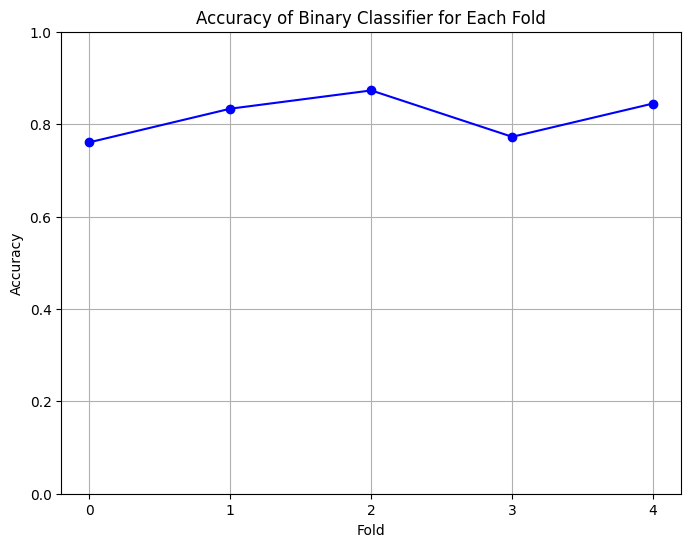

In [63]:
%matplotlib inline

group_kfold = GroupKFold(n_splits)
groups = homing_ids
X = design_matrix
y = np.asarray(classes_extended).reshape(-1, 1)

fold_accuracies = []

for fold, (train_index, test_index) in enumerate(group_kfold.split(X, y, groups)):
    X_train, X_test = X[train_index, :], X[test_index, :]
    y_train, y_test = y[train_index, :], y[test_index, :]
    
    print(f"Fold: {fold}")
    
    model = LogisticRegression( penalty='l2',
                            dual=False, 
                            tol=0.0001, 
                            C=1.0, 
                            fit_intercept=True, 
                            intercept_scaling=1,  
                            class_weight=None, 
                            random_state=1337, 
                            solver='lbfgs', 
                            max_iter=10000, 
                            verbose=0, 
                            warm_start=False, 
                            n_jobs=None, 
                            l1_ratio=None
                        ).fit(X_train, y_train.reshape(-1))
    
    # Predict on test data and calculate accuracy
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    fold_accuracies.append(accuracy)
    print(f"Fold: {fold}, Accuracy: {accuracy:.4f}")
    

# Plot accuracies
plt.figure(figsize=(8, 6))
plt.plot(range(n_splits), fold_accuracies, marker='o', linestyle='-', color='b')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy of Binary Classifier for Each Fold')
plt.xticks(range(n_splits))
plt.ylim(0, 1)
plt.grid(True)
plt.show()
    



